(sec:trimer-case1-qme)=
# Trimer Case I: QME

We assume that three emitters are separated by a large distance so that $\Gamma_{12}=\Gamma_{23}=\Gamma_{31}=0$. No coherence between the emitters.

## Preparation


**Parameters**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# Parameters
omega0 = 1.0
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
NT = 1/(np.exp(omega0/temperature)-1) # Planck distribution

gamma_a = gamma0 * NT   # coefficient to absorption
gamma_e = gamma0 * (NT+1)  # coefficient to emission


**Operators for N=3**

In [2]:
# Kronecker products of three operators
def kprod3(o1,o2,o3):
    return tensor(tensor(o1,o2),o3)

#--- Spin operators ---
i2 = qeye(2)
sz = [kprod3(sigmaz(),i2,i2),kprod3(i2,sigmaz(),i2),kprod3(i2,i2,sigmaz())]
sp = [kprod3(sigmap(),i2,i2),kprod3(i2,sigmap(),i2),kprod3(i2,i2,sigmap())]
sm = [kprod3(sigmam(),i2,i2),kprod3(i2,sigmam(),i2),kprod3(i2,i2,sigmam())]

#--- Hamiltonian ---
H = 0.5*omega0*np.sum(sz)

#--- Jump operators ---
c_ops = []
# absorption
for k in range(3):
    c_ops.append(np.sqrt(gamma_a)*sp[k])
# emission
for k in range(3):
    c_ops.append(np.sqrt(gamma_e)*sm[k])    


**Energy eigenbasis**

In [3]:
basis2=['e','g']
basis8=[]
pbasis=[]
#--- basis vectors and their name ---
for i1 in range(2):
    for i2 in range(2):
        for i3 in range(2):
            basis8.append(basis2[i1]+basis2[i2]+basis2[i3])
            pbasis.append(kprod3(basis(2,i1),basis(2,i2),basis(2,i3)))

#--- energy eigenvalues ---
energy = np.array([])
for k in range(8):
    energy = np.append(energy,expect(H,pbasis[k]))

print("Energy spaectrum")
print("State   Energy")
for k in range(8):
    print(" {0:4s}   {1:4.1f}".format(basis8[k],energy[k]))

Energy spaectrum
State   Energy
 eee     1.5
 eeg     0.5
 ege     0.5
 egg    -0.5
 gee     0.5
 geg    -0.5
 gge    -0.5
 ggg    -1.5



**Steady state**

The diagonal element of steady state should agree with the Boltzmann distribution.  Its off-diagonal elements should all vanish.

In [4]:
#--- Get the steady state ---
rho_ss = steadystate(H,c_ops)

#--- Thermal state ---
# partition function
Z = np.sum(np.exp(-energy/temperature))
# Boltzmann distribution
p = np.exp(-energy/temperature)/Z

print("Diagonal elements of steady state")
print(" State    ρ_ii     Boltzmann")

for k in range(8):
    print(" {0:4s}   {1:7.4f}   {2:8.4f}".format(basis8[k],rho_ss[k,k].real,p[k]))

tol = 1e-10
flag = False
for i1 in range(8):
    for i2 in range(i1+1,8):
        if rho_ss[i1,i2] > tol:
            print("element {0:1d}{1:1d} = {2:8.4f}".format(i1,i2,rho_ss[i1,i2]))
            flag = True

if flag:  
    print("At least one off-diagonal element is not zero.")
else:
    print("All off-diagonal element is zero.")

Diagonal elements of steady state
 State    ρ_ii     Boltzmann
 eee     0.0195     0.0195
 eeg     0.0529     0.0529
 ege     0.0529     0.0529
 egg     0.1437     0.1437
 gee     0.0529     0.0529
 geg     0.1437     0.1437
 gge     0.1437     0.1437
 ggg     0.3907     0.3907
All off-diagonal element is zero.



**Checking the cross correlation**

All cross correlation should vanish.

In [5]:
print("Pair     Correlation")
for i1 in range(3):
    for i2 in range(i1+1,3):
        y=expect(sp[i1]*sm[i2],rho_ss)
        print(" {0:1d}-{1:1d}  {2:7.4f}".format(i1+1,i2+1,y))

Pair     Correlation
 1-2  0.0000+0.0000j
 1-3  0.0000+0.0000j
 2-3  0.0000+0.0000j


## Second-order coherence

Since the emitters are all independent and the detector can select photons from individual emitters, we don't have to worry about the detection geometry. In this case, the no-delay coherence should be $1-\tfrac13 = \tfrac23$.

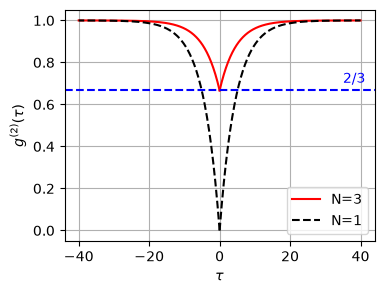

In [6]:
times = np.linspace(0, 40, 400)

G2 = np.zeros_like(times, dtype=complex)

# no geometric phase factor is needed for incoherent three sources.
for i in range(3):
    for j in range(3):
        G2 += correlation_3op_1t(H,rho_ss,times,c_ops,sp[i],sp[j]*sm[j],sm[i],solver="me")
        
# normalize the correlation 
# mean intensity of steady state
I_sum = expect(sp[0]*sm[0]+sp[1]*sm[1]+sp[2]*sm[2],rho_ss)
g2 = G2/I_sum**2

g2_exact = 1-np.exp(-(gamma_a+gamma_e)*times)
g2_nodelay = 2/3

plt.figure(figsize=(4,3))
plt.plot(times, np.real(g2),c='r',label="N=3")
plt.plot(-times,np.real(g2),c='r')
plt.plot(times, np.real(g2_exact),c='k',ls='--',label="N=1")
plt.plot(-times, np.real(g2_exact),c='k',ls='--')
plt.axhline(g2_nodelay,ls='--',color='b')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.text(35,0.7,"$2/3$",color="b")
plt.legend(loc=4)
plt.grid(True)
plt.show()